In [1]:
from mnist_synthetic.torch.datasets.CyrillicEMNISTSynthetic import CyrillicEMNISTSynthetic

In [2]:
import sys
import importlib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, ConcatDataset

import torchvision
from torchvision import transforms
import torchvision.transforms as T
from torchvision.transforms import functional as F

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# Перезагрузка модуля генератора
import mnist_synthetic.lower_case_letters_generator
importlib.reload(mnist_synthetic.lower_case_letters_generator)
from mnist_synthetic.lower_case_letters_generator import LowerCaseLettersGenerator


In [3]:
generator = LowerCaseLettersGenerator(seed=42)

transform_nearest = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(28, interpolation=transforms.InterpolationMode.NEAREST),
])

transform_bilinear = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(28, interpolation=transforms.InterpolationMode.BILINEAR),
])

transform_bicubic = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(28, interpolation=transforms.InterpolationMode.BICUBIC),
])

In [4]:
transform_perspective = transforms.Compose([
    transforms.ToTensor(),
    T.RandomPerspective(distortion_scale=0.5, p=0.5),  # p=1.0 для демонстрации
])

perspective_aug = CyrillicEMNISTSynthetic(size=10, seed=42, include=
                  ['а', 'б', 'в', 'г', 'д', 'е', 'ё', 'ж', 'з',
                   'и', 'й', 'к', 'л', 'м', 'н', 'о', 'п', 'р',
                   'с', 'т', 'у', 'ф', 'х', 'ц', 'ч', 'ш', 'щ',
                   'ъ', 'ы', 'ь', 'э', 'ю', 'я'],
                                           transform=transform_perspective),

In [5]:

print("=" * 50)
print(f"Путь к интерпретатору: {sys.executable}")
print(f"Версия Python: {sys.version}")
print(f"Путь к torch: {torch.__file__}")
print(f"Версия torch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print("=" * 50)

Путь к интерпретатору: C:\Users\Computer\AppData\Local\Programs\Python\Python312\python.exe
Версия Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Путь к torch: C:\Users\Computer\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\__init__.py
Версия torch: 2.10.0+cu126
CUDA available: True
CUDA version: 12.6
GPU: NVIDIA GeForce RTX 3060


In [6]:
# 1) КОНСТАНТЫ И ГИПЕРПАРАМЕТРЫ


# Гиперпараметры
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
NUM_EPOCHS = 10
NUM_SAMPLES = 60000  # Общее количество семплов
VAL_RATIO = 0.15  # Доля валидационной выборки
SEED = 42

# Список букв для генерации
ALLOWED_LETTERS = ['а', 'б', 'в', 'г', 'д', 'е', 'ё', 'ж', 'з',
                   'и', 'й', 'к', 'л', 'м', 'н', 'о', 'п', 'р',
                   'с', 'т', 'у', 'ф', 'х', 'ц', 'ч', 'ш', 'щ',
                   'ъ', 'ы', 'ь', 'э', 'ю', 'я']

# Маппинг букв в классы (для loss function)
LETTER_TO_CLASS = {letter: idx for idx, letter in enumerate(ALLOWED_LETTERS)}
CLASS_TO_LETTER = {idx: letter for letter, idx in LETTER_TO_CLASS.items()}
NUM_CLASSES = len(ALLOWED_LETTERS)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Фиксация seed для воспроизводимости
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)


Using device: cuda


In [7]:
# 2) МОДЕЛЬ (LeNet)

class LeNet(nn.Module):

    def __init__(self, num_classes: int = NUM_CLASSES):
        super(LeNet, self).__init__()

        self.features = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            # Conv Block 2
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Инициализация модели
model = LeNet(num_classes=NUM_CLASSES).to(device)
print(f'Model architecture:\n{model}')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

Model architecture:
LeNet(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): ReLU()
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): ReLU()
    (5): Linear(in_features=84, out_features=33, bias=True)
  )
)
Total parameters: 63,661


In [8]:
# 3) ДАТАСЕТЫ И DATALOADER

# Кастомный трансформ для конвертации строковых лейблов в классы
class LabelEncoder:
    """Конвертирует строковые лейблы в числовые классы."""

    def __init__(self, letter_to_class: dict):
        self.letter_to_class = letter_to_class

    def __call__(self, label: str) -> int:
        return self.letter_to_class.get(label, 0)



# --- Трансформы ---
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(28, interpolation=transforms.InterpolationMode.NEAREST),

    # 1. Случайные сдвиги и повороты
    transforms.RandomAffine(
        degrees=30,           # Поворот до 30 градусов
        translate=(0.2, 0.2), # Сдвиг до 20%
        scale=(0.8, 1.2),     # Масштаб от 0.8 до 1.2
        shear=10              # Наклон
    ),

    # 2. Случайные перспективные искажения
    transforms.RandomPerspective(distortion_scale=0.3, p=0.5),

    # 3. Добавление шума (через Lambda)
    transforms.Lambda(lambda x: x + torch.randn_like(x) * 0.1),
    transforms.Lambda(lambda x: torch.clamp(x, 0, 1)),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(28, interpolation=transforms.InterpolationMode.NEAREST),
])

# Создание независимых датасетов
print('Generating synthetic datasets...')

train_dataset = CyrillicEMNISTSynthetic(
    size=int(NUM_SAMPLES * (1 - VAL_RATIO)),
    seed=SEED,                      # Seed для тренировки
    include=ALLOWED_LETTERS,
    transform=train_transform
)

val_dataset = CyrillicEMNISTSynthetic(
    size=int(NUM_SAMPLES * VAL_RATIO),
    seed=SEED + 9999,               # Другой seed для валидации
    include=ALLOWED_LETTERS,
    transform=val_transform
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f'Train samples: {len(train_dataset)}')
print(f'Val samples: {len(val_dataset)}')
print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')

Generating synthetic datasets...
Train samples: 51000
Val samples: 9000
Train batches: 399
Val batches: 71


In [9]:
# 4) ЛОСС-ФУНКЦИЯ И ОПТИМИЗАТОР

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [10]:
# 5) МЕТРИКИ

class Metrics:
    """Класс для отслеживания метрик обучения."""

    def __init__(self):
        self.train_loss = []
        self.val_loss = []
        self.train_acc = []
        self.val_acc = []

    def update(self, train_loss, train_acc, val_loss, val_acc):
        self.train_loss.append(train_loss)
        self.train_acc.append(train_acc)
        self.val_loss.append(val_loss)
        self.val_acc.append(val_acc)

    def plot(self):
        """Визуализация метрик обучения."""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Loss
        axes[0].plot(self.train_loss, label='Train Loss', marker='o')
        axes[0].plot(self.val_loss, label='Val Loss', marker='s')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Loss Curve')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Accuracy
        axes[1].plot(self.train_acc, label='Train Acc', marker='o')
        axes[1].plot(self.val_acc, label='Val Acc', marker='s')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Accuracy Curve')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


def calculate_accuracy(outputs, labels):
    """Вычисляет accuracy для батча."""
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    total = labels.size(0)
    return correct / total




Начало обучения | Epochs: 10 | Device: cuda


Epoch 1/10
----------------------------------------


Train Loss: 2.4608 | Train Acc: 0.2735
Val Loss:   1.0005 | Val Acc:   0.7048
New best model! Val Acc: 0.7048

Epoch 2/10
----------------------------------------


Train Loss: 1.4983 | Train Acc: 0.5306
Val Loss:   0.4616 | Val Acc:   0.8647
New best model! Val Acc: 0.8647

Epoch 3/10
----------------------------------------


Train Loss: 1.0811 | Train Acc: 0.6547
Val Loss:   0.2077 | Val Acc:   0.9438
New best model! Val Acc: 0.9438

Epoch 4/10
----------------------------------------


Train Loss: 0.8065 | Train Acc: 0.7393
Val Loss:   0.2859 | Val Acc:   0.9029

Epoch 5/10
----------------------------------------


...

Train Loss: 0.4915 | Train Acc: 0.8422
Val Loss:   0.0884 | Val Acc:   0.9696
New best model! Val Acc: 0.9696

Epoch 7/10
----------------------------------------


Train Loss: 0.4501 | Train Acc: 0.8528
Val Loss:   0.0566 | Val Acc:   0.9826
New best model! Val Acc: 0.9826

Epoch 8/10
----------------------------------------


Train Loss: 0.3988 | Train Acc: 0.8691
Val Loss:   0.0636 | Val Acc:   0.9817

Epoch 9/10
----------------------------------------


Train Loss: 0.3734 | Train Acc: 0.8772
Val Loss:   0.0510 | Val Acc:   0.9862
New best model! Val Acc: 0.9862

Epoch 10/10
----------------------------------------


Train Loss: 0.3548 | Train Acc: 0.8832
Val Loss:   0.0405 | Val Acc:   0.9877
New best model! Val Acc: 0.9877

Loaded best model with Val Acc: 0.9877

Обучение завершено!



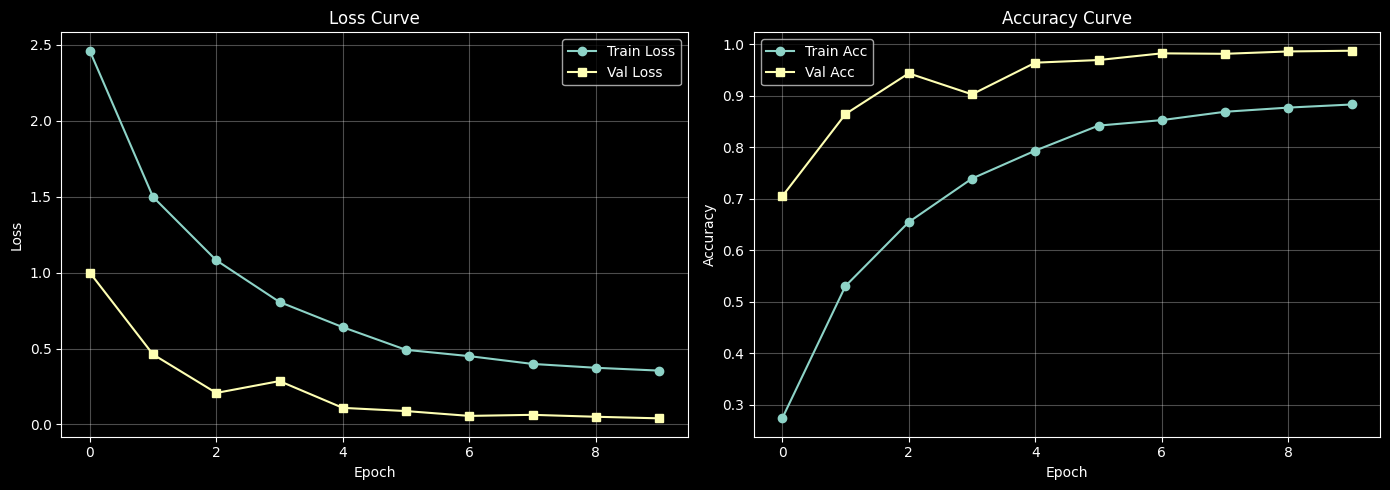

In [11]:
# 6) ЯЧЕЙКА ОБУЧЕНИЯ И ВАЛИДАЦИИ

def train_epoch(model, loader, criterion, optimizer, device):
    """Один epoch обучения."""
    model.train()
    total_loss = 0.0
    total_acc = 0.0

    for images, labels in tqdm(loader, desc='Training', leave=False):
        # Конвертация строковых лейблов в числовые
        labels_numeric = torch.tensor([LETTER_TO_CLASS[l] for l in labels], dtype=torch.long)

        images = images.to(device)
        labels_numeric = labels_numeric.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels_numeric)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_acc += calculate_accuracy(outputs, labels_numeric) * images.size(0)

    return total_loss / len(loader.dataset), total_acc / len(loader.dataset)


def validate_epoch(model, loader, criterion, device):
    """Один epoch валидации."""
    model.eval()
    total_loss = 0.0
    total_acc = 0.0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validating', leave=False):
            # Конвертация строковых лейблов в числовые
            labels_numeric = torch.tensor([LETTER_TO_CLASS[l] for l in labels], dtype=torch.long)

            images = images.to(device)
            labels_numeric = labels_numeric.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels_numeric)

            total_loss += loss.item() * images.size(0)
            total_acc += calculate_accuracy(outputs, labels_numeric) * images.size(0)

    return total_loss / len(loader.dataset), total_acc / len(loader.dataset)


def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler, num_epochs, device, metrics):
    """Полный цикл обучения модели."""

    print(f'\n{"="*60}')
    print(f'Начало обучения | Epochs: {num_epochs} | Device: {device}')
    print(f'{"="*60}\n')

    best_val_acc = 0.0
    best_model_state = None

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch + 1}/{num_epochs}')
        print('-' * 40)

        # Training
        train_loss, train_acc = train_epoch(model, train_loader, criterion,
                                            optimizer, device)

        # Validation
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

        # Scheduler step
        scheduler.step()

        # Update metrics
        metrics.update(train_loss, train_acc, val_loss, val_acc)

        # Print results
        print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
        print(f'Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}')

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            print(f'New best model! Val Acc: {best_val_acc:.4f}')

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f'\nLoaded best model with Val Acc: {best_val_acc:.4f}')

    print(f'\n{"="*60}')
    print(f'Обучение завершено!')
    print(f'{"="*60}\n')

    return model, metrics


# Запуск обучения
metrics = Metrics()
model, metrics = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    device=device,
    metrics=metrics
)

# Визуализация метрик
metrics.plot()


Примеры предсказаний:


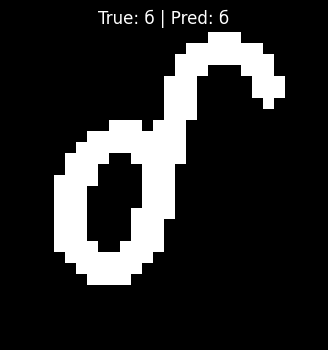

1. True: б | Predicted: б | Correct!


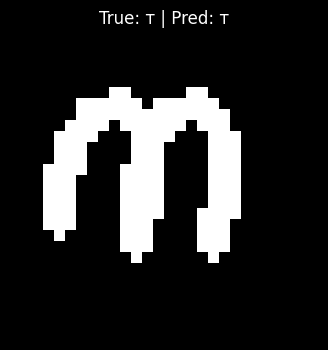

2. True: т | Predicted: т | Correct!


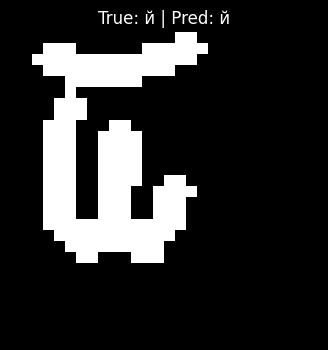

3. True: й | Predicted: й | Correct!


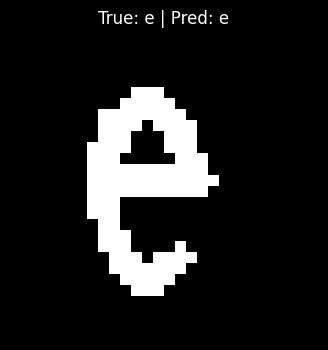

4. True: е | Predicted: е | Correct!


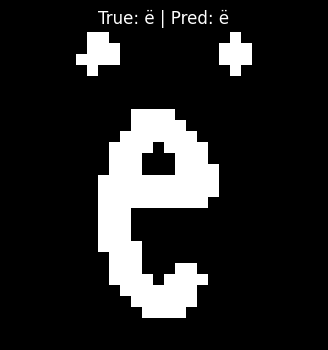

5. True: ё | Predicted: ё | Correct!


In [12]:
# 7) Тестирование на примерах

def predict_sample(model, dataset, idx, device, letter_to_class, class_to_letter):
    """Предсказание на одном примере."""
    model.eval()

    img, label = dataset[idx]
    img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)
        _, predicted = torch.max(output, 1)
        predicted_class = predicted.item()
        predicted_letter = class_to_letter[predicted_class]

    # Визуализация
    plt.figure(figsize=(4, 4))
    plt.imshow(img.squeeze(0).squeeze(0).cpu().numpy(), cmap='gray')
    plt.title(f'True: {label} | Pred: {predicted_letter}')
    plt.axis('off')
    plt.show()

    return label, predicted_letter


# Пример предсказания
print('\nПримеры предсказаний:')
for i in range(5):
    idx = torch.randint(0, len(val_dataset), (1,)).item()
    true_label, pred_label = predict_sample(model, val_dataset, idx, device,
                                            LETTER_TO_CLASS, CLASS_TO_LETTER)
    print(f'{i+1}. True: {true_label} | Predicted: {pred_label} | {"Correct!" if true_label == pred_label else "Incorrect!"}')